In [64]:
import time 

import cv2
import IPython
import pandas as pd
from tqdm.auto import tqdm
from deepface import DeepFace
from retinaface import RetinaFace

In [10]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [35]:
def draw_faces(image, faces):
    img = image.copy()
    for face in faces:
        # バウンディングボックス
        x1 = face['facial_area']['x']
        y1 = face['facial_area']['y']
        x2 = x1 + face['facial_area']['w']
        y2 = y1 + face['facial_area']['h']
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(img)

In [47]:
def draw_faces_row(row):
    img = cv2.imread(str(row['filepath']))
    x1 = int(row['x1'])
    y1 = int(row['y1'])
    x2 = int(row['x2'])
    y2 = int(row['y2'])
    color = (0, 0, 255)
    thickness = 2
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(img)

In [36]:
def draw_faces_retina(image, faces):
    img = image.copy()
    for face, data in faces.items():
        # バウンディングボックス
        x1, y1, x2, y2 = data['facial_area']
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(img)

In [2]:
df = pd.read_csv('../data/faces.csv', index_col=0)
comparison_df = df.assign(status=None)
comparison_df['filepath'] = comparison_df['name'].map(lambda x: '/home/amos/programs/CineFace/research/test_images/' + x)
comparison_df.head()

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num,status,filepath
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080.0,1920.0,323.0,5.0,919.0,731.0,596.0,726.0,432696.0,0.208669,0.0,None,/home/amos/programs/CineFace/research/test_ima...
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1080.0,1920.0,262.0,42.0,614.0,507.0,352.0,465.0,163680.0,0.078935,0.0,None,/home/amos/programs/CineFace/research/test_ima...
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,484.0,389.0,671.0,617.0,187.0,228.0,42636.0,0.020561,0.0,None,/home/amos/programs/CineFace/research/test_ima...
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,1003.0,42.0,1195.0,261.0,192.0,219.0,42048.0,0.020278,1.0,None,/home/amos/programs/CineFace/research/test_ima...
4,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,1080.0,1920.0,1121.0,66.0,1662.0,824.0,541.0,758.0,410078.0,0.197761,0.0,None,/home/amos/programs/CineFace/research/test_ima...


In [3]:
backends = [
  'opencv', 
  'ssd', 
  'dlib', 
  'mtcnn', 
  'fastmtcnn',
  'retinaface', 
  'mediapipe',
  'yolov8',
  'yolov11s',
  'yolov11n',
  'yolov11m',
  'yunet',
  'centerface',
]

In [65]:
image_paths = comparison_df['filepath'].unique().tolist()
dfs = []
for backend in tqdm(backends):
    data = []
    for image_path in tqdm(image_paths[:5], leave=False):
        start = time.time()
        img = cv2.imread(image_path)
        faces = DeepFace.extract_faces(img,
                                        detector_backend='opencv',
                                        enforce_detection=False,
                                        align=True,
                                        normalize_face=True)
        temp = comparison_df[comparison_df['filepath'] == image_path]
        found = []
        for face in faces:
            x1 = face['facial_area']['x']
            y1 = face['facial_area']['y']
            x2 = x1 + face['facial_area']['w']
            y2 = y1 + face['facial_area']['h']
            for idx, row in temp.iterrows():
                row['status'] = 'fp'
                if (int(row['x1']) <= x1 <= int(row['x2'])) or (int(row['x1'] <= x2 <= int(row['x2']))) and \
                    (int(row['y1'] <= y1 <= int(row['y2'])) or (int(row['y1']) <= y2 <= int(row['y2']))):
                    row['status'] = 'tp'
                    found.append(idx)
                row['backend'] = backend
                row['duration'] = time.time() - start
                data.append(row)
        t = temp.drop(found, axis=0)
        for i, r in t.iterrows():
            r['status'] = 'fn'
            r['backend'] = backend
            r['duration'] = time.time() - start
            data.append(r)   
    df = pd.DataFrame(data)
    dfs.append((backend, df)) 


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [66]:
dfs[0][1].head()

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num,status,filepath,backend,duration
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080.0,1920.0,323.0,5.0,919.0,731.0,596.0,726.0,432696.0,0.208669,0.0,fp,/home/amos/programs/CineFace/research/test_ima...,opencv,0.255404
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080.0,1920.0,323.0,5.0,919.0,731.0,596.0,726.0,432696.0,0.208669,0.0,fn,/home/amos/programs/CineFace/research/test_ima...,opencv,0.256216
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1080.0,1920.0,262.0,42.0,614.0,507.0,352.0,465.0,163680.0,0.078935,0.0,tp,/home/amos/programs/CineFace/research/test_ima...,opencv,0.161230
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,484.0,389.0,671.0,617.0,187.0,228.0,42636.0,0.020561,0.0,fp,/home/amos/programs/CineFace/research/test_ima...,opencv,0.250179
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,1003.0,42.0,1195.0,261.0,192.0,219.0,42048.0,0.020278,1.0,fp,/home/amos/programs/CineFace/research/test_ima...,opencv,0.251421


In [1]:
dfs[1][1]['status'].value_counts()

NameError: name 'dfs' is not defined

In [ ]:
d = {}
for backend, df in dfs:
    cnts = 

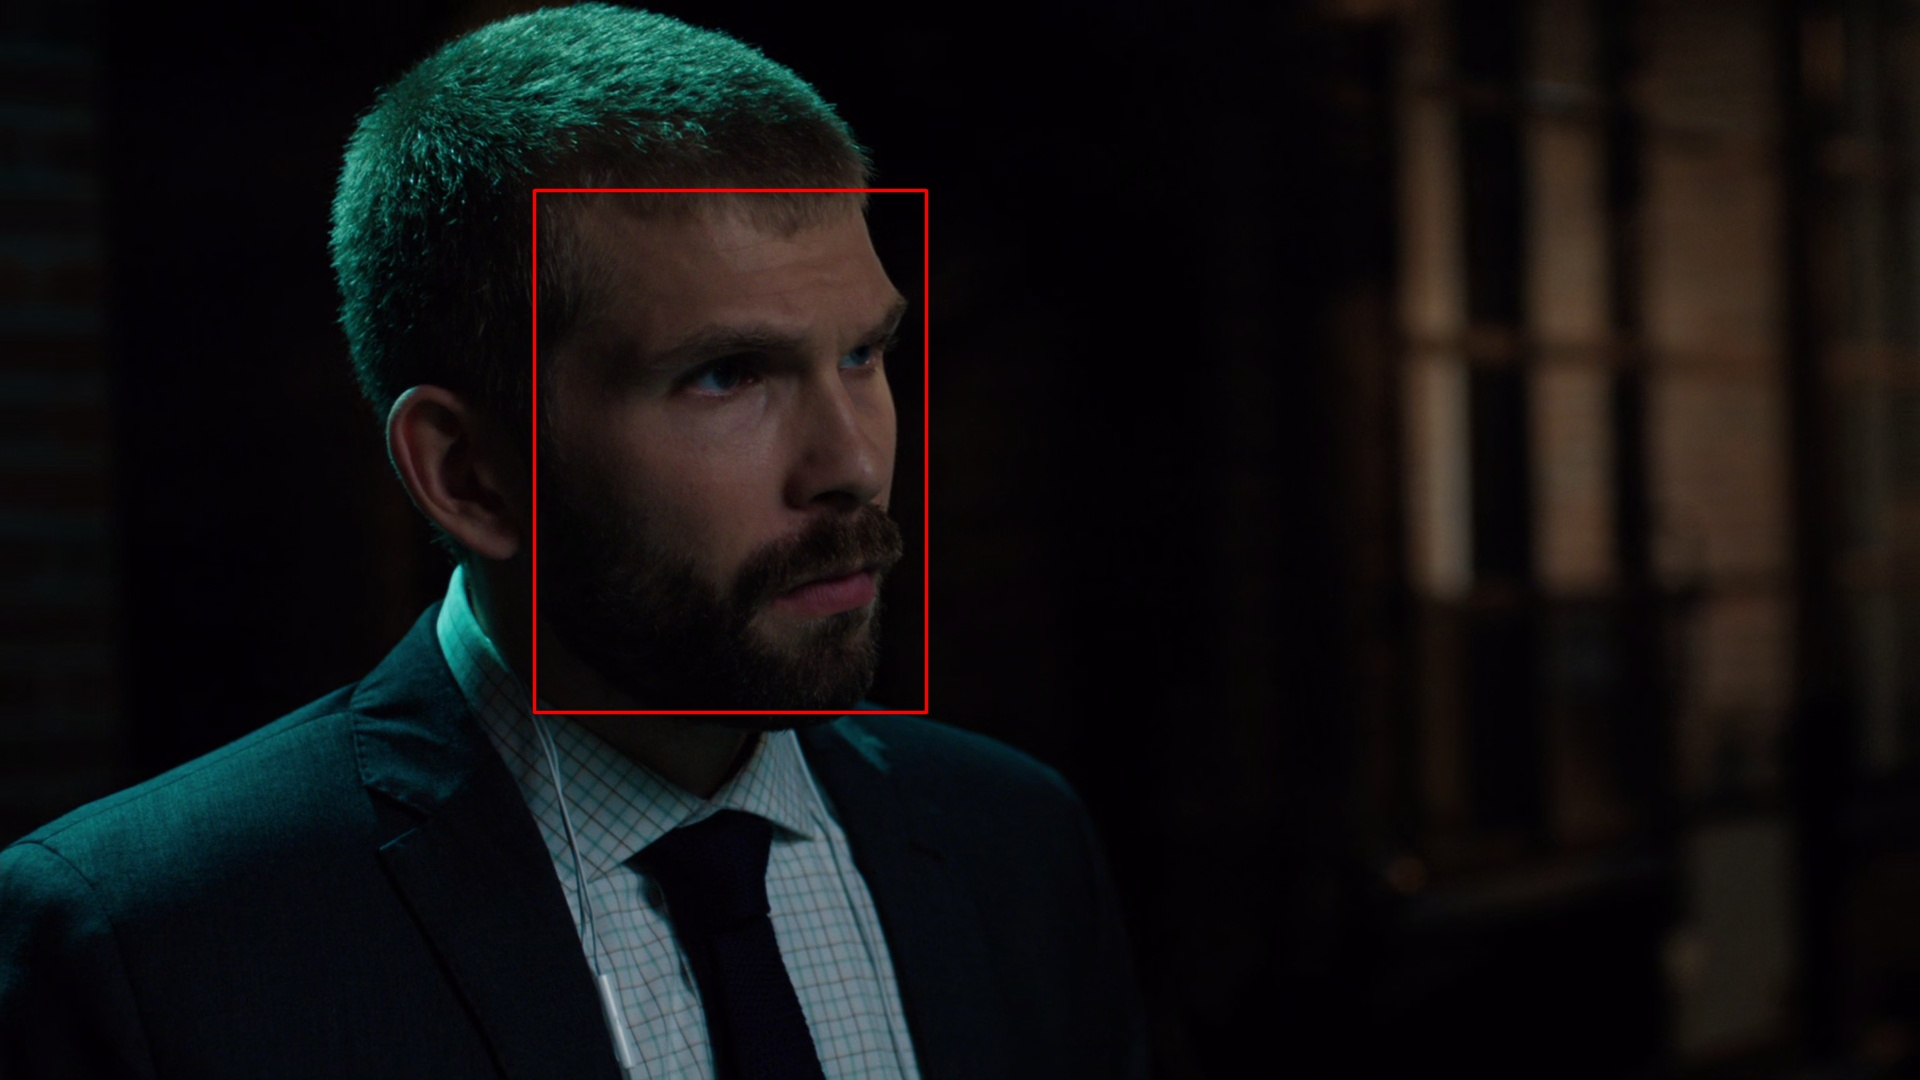

In [42]:
faces = DeepFace.extract_faces(images[0],
                                       detector_backend='retinaface',
                                       enforce_detection=False,
                                       align=False,
                                       normalize_face=False)
draw_faces(images[0], faces)

In [51]:
print(comparison_df.iloc[0]['x1'],
      comparison_df.iloc[0]['y1'],
      comparison_df.iloc[0]['x2'],
      comparison_df.iloc[0]['y1'])
face = faces[0]
x1 = face['facial_area']['x']
y1 = face['facial_area']['y']
x2 = x1 + face['facial_area']['w']
y2 = y1 + face['facial_area']['h']
print(x1, y1, x2, y2)

323.0 5.0 919.0 5.0
534 190 926 712


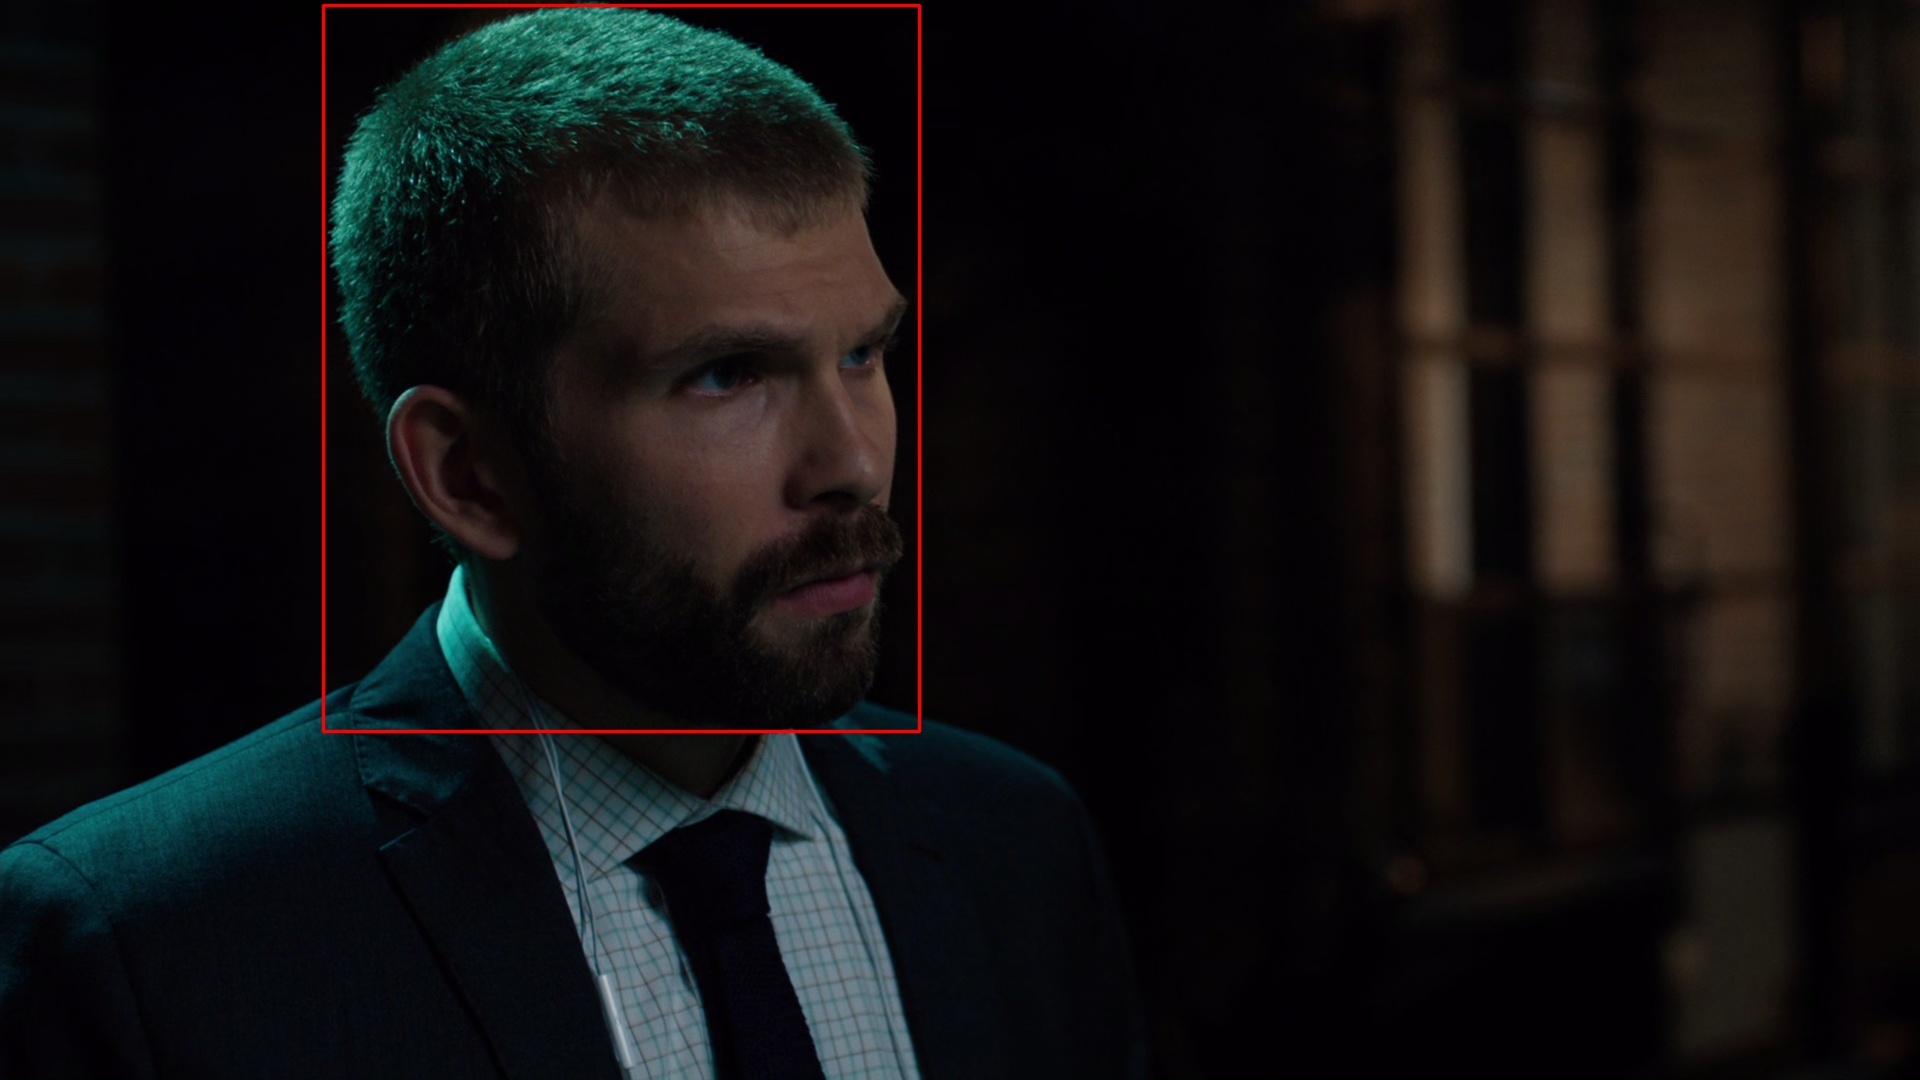

In [48]:
draw_faces_row(comparison_df.iloc[0])

In [22]:
faces = RetinaFace.detect_faces(images[0])
faces

{'face_1': {'score': 0.9998034834861755,
  'facial_area': [534, 190, 926, 712],
  'landmarks': {'right_eye': [742.70966, 382.7692],
   'left_eye': [882.5467, 370.1978],
   'nose': [892.67413, 458.55524],
   'mouth_right': [782.4827, 587.888],
   'mouth_left': [883.2984, 575.9158]}}}

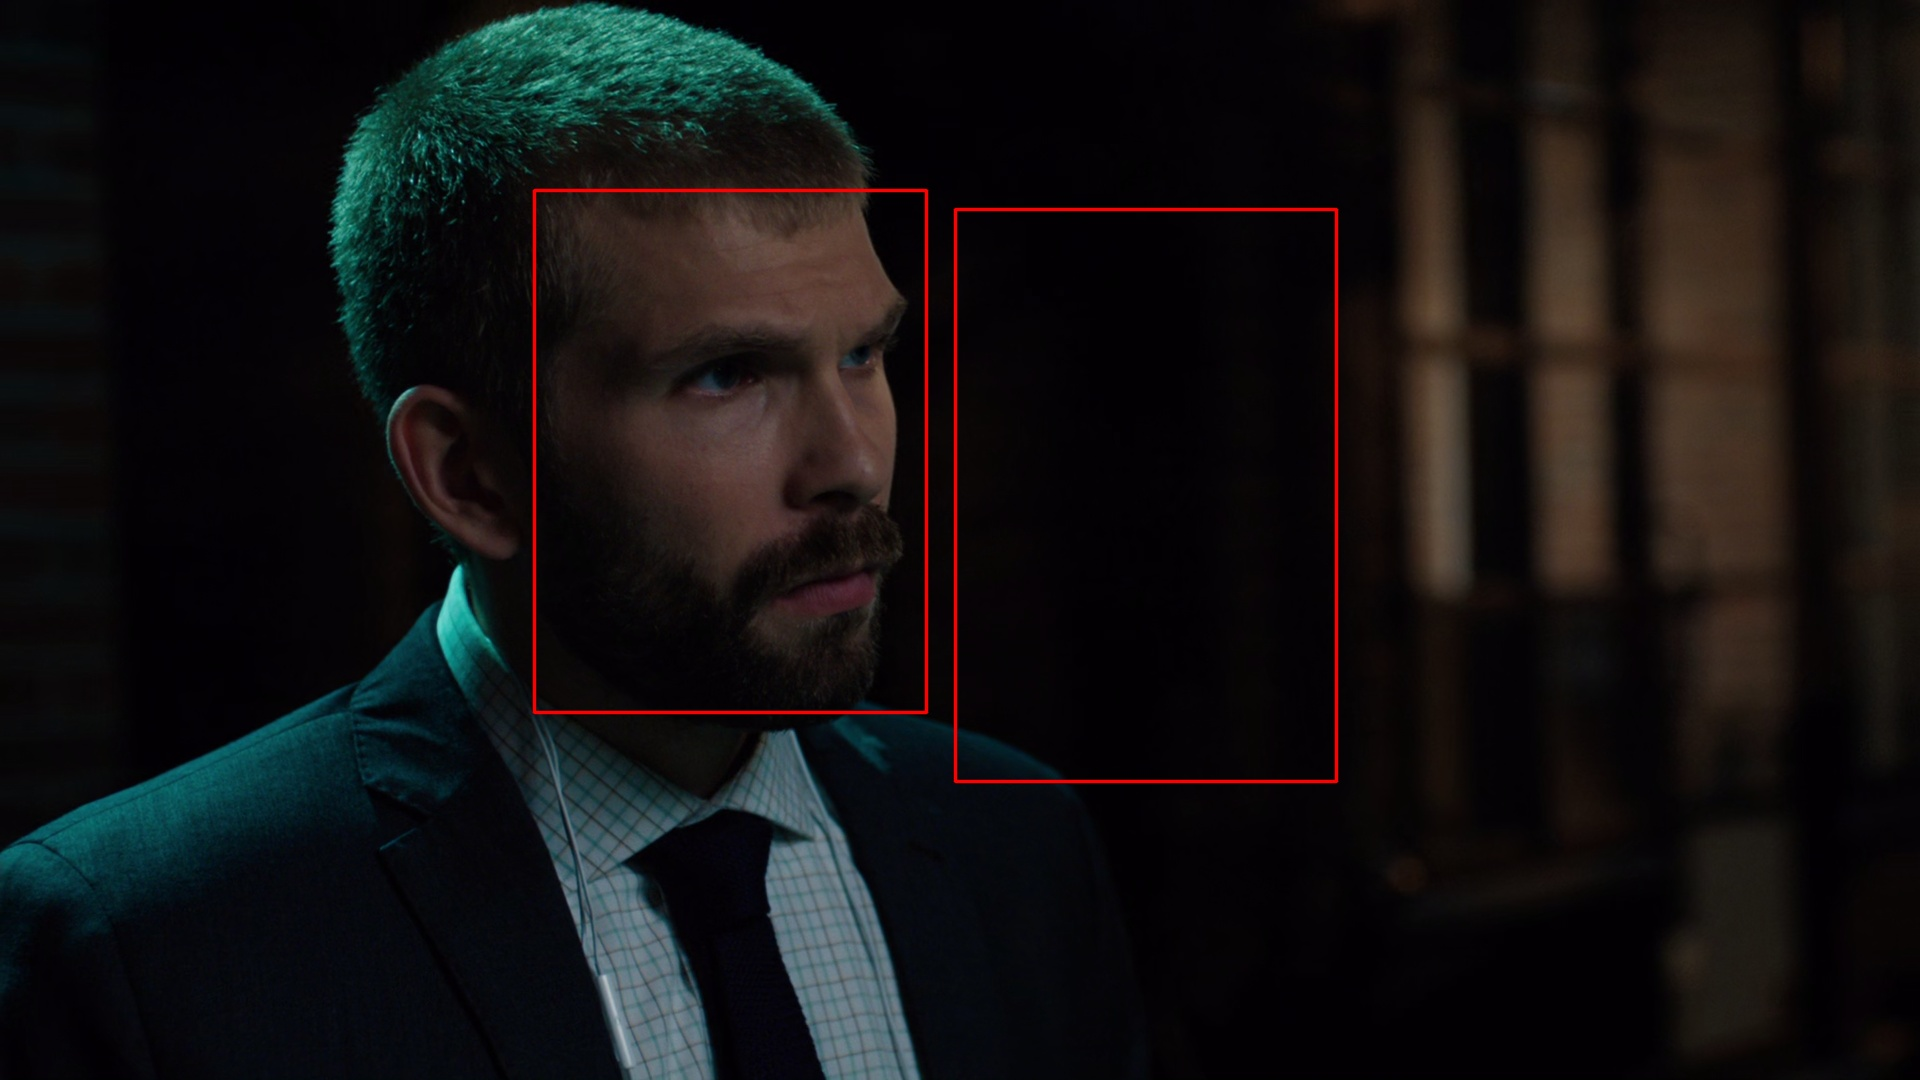

In [25]:
draw_faces_retina(images[0], faces)